# Tital Prediction on Actual Test Set

**Note:** `datahow_interview_test_targets-TEMPLATE.csv` is a *submission template*, not the real ground truth - every row currently has the same placeholder value (`Y:Titer = 2000`). 

In [1]:
import pathlib

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
DATA_DIR = "../dataset"
MODELS_DIR = pathlib.Path("models")

test_exp = pd.read_csv(f"{DATA_DIR}/test_exp_features.csv", index_col="Exp")
feature_cols = [c for c in test_exp.columns if c != "n_days"]

# to be replaced with the actual test file
targets = pd.read_csv(
    f"{DATA_DIR}/datahow_interview_test_targets-TEMPLATE.csv", index_col="Exp"
)

print("test_exp:", test_exp.shape)
print(f"Using {len(feature_cols)} features")
# test_exp.head()

test_exp: (20, 68)
Using 67 features


## 1. Load trained models

Load the 7 regressors that were fit on the full training set and persisted with `joblib` in `baseline.ipynb`.

In [3]:
model_files = {
    "Linear Regression": "Linear_Regression.joblib",
    "Multiple Linear Regression": "Multiple_Linear_Regression.joblib",
    "Ridge": "Ridge.joblib",
    "PLS (5 comp)": "PLS_5_comp.joblib",
    "RandomForest": "RandomForest.joblib",
    "GradientBoosting": "GradientBoosting.joblib",
    "XGBoost": "XGBoost.joblib",
}
models = {name: joblib.load(MODELS_DIR / fname) for name, fname in model_files.items()}
list(models.keys())

['Linear Regression',
 'Multiple Linear Regression',
 'Ridge',
 'PLS (5 comp)',
 'RandomForest',
 'GradientBoosting',
 'XGBoost']

## 2. Generate predictions

- Only the simple `Linear Regression` model was trained on a single feature (`VCD_time_to_peak`)
- Every other model was trained on the full 67-feature set, in the same column order as the training data.

In [4]:
X_full = test_exp[feature_cols]
X_single = test_exp[["VCD_time_to_peak"]]

predictions = {}
for name, model in models.items():
    X_input = X_single if name == "Linear Regression" else X_full
    predictions[name] = model.predict(X_input).ravel()

pred_df = pd.DataFrame(predictions, index=test_exp.index)
pred_df

/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/nutt/github/datahow-titer-ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was

,Linear Regression,Multiple Linear Regression,Ridge,PLS (5 comp),RandomForest,GradientBoosting,XGBoost
Exp,,,,,,,
Test Exp 1,2289.087043,1061.592795,2244.114978,2448.794105,2418.263770,2509.959303,2293.958008
Test Exp 2,1592.958634,2900.113900,3141.410235,3272.292260,2796.485769,2665.466782,1918.859863
Test Exp 3,3333.279656,1529.447957,1691.717985,1629.647278,1778.933114,1566.297806,1513.252319
Test Exp 4,1244.894430,1093.657678,3237.390518,3279.233141,2124.092275,1784.833250,1823.567627
Test Exp 5,2637.151247,2700.222534,2966.109617,2947.580346,2861.809514,2495.654484,2495.306641
Test Exp 6,1244.894430,2017.469478,1986.081918,1875.963297,1424.966912,1014.158288,1036.974854
Test Exp 7,2637.151247,2292.121234,3485.188230,3370.437716,2865.793002,2447.467612,2568.235840
Test Exp 8,548.766021,-431.155307,1905.684499,2013.974128,2026.095769,1698.440836,1393.233887
Test Exp 9,896.830225,-1391.552768,-542.000928,-405.107920,565.055023,590.504182,523.913025


## 3. Compare against the target template

Note: the comparison and metrics below only illustrate the workflow; re-run this section once the actual test targets are available.

In [5]:
comparison = pred_df.copy()
comparison["Y:Titer (template)"] = targets["Y:Titer"]
comparison

,Linear Regression,Multiple Linear Regression,Ridge,PLS (5 comp),RandomForest,GradientBoosting,XGBoost,Y:Titer (template)
Exp,,,,,,,,
Test Exp 1,2289.087043,1061.592795,2244.114978,2448.794105,2418.263770,2509.959303,2293.958008,2000
Test Exp 2,1592.958634,2900.113900,3141.410235,3272.292260,2796.485769,2665.466782,1918.859863,2000
Test Exp 3,3333.279656,1529.447957,1691.717985,1629.647278,1778.933114,1566.297806,1513.252319,2000
Test Exp 4,1244.894430,1093.657678,3237.390518,3279.233141,2124.092275,1784.833250,1823.567627,2000
Test Exp 5,2637.151247,2700.222534,2966.109617,2947.580346,2861.809514,2495.654484,2495.306641,2000
Test Exp 6,1244.894430,2017.469478,1986.081918,1875.963297,1424.966912,1014.158288,1036.974854,2000
Test Exp 7,2637.151247,2292.121234,3485.188230,3370.437716,2865.793002,2447.467612,2568.235840,2000
Test Exp 8,548.766021,-431.155307,1905.684499,2013.974128,2026.095769,1698.440836,1393.233887,2000
Test Exp 9,896.830225,-1391.552768,-542.000928,-405.107920,565.055023,590.504182,523.913025,2000


In [6]:
y_true = targets["Y:Titer"].loc[pred_df.index]

metrics = []
for name in pred_df.columns:
    y_pred = pred_df[name]
    metrics.append(
        {
            "model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "R2": r2_score(y_true, y_pred),
        }
    )

metrics_df = pd.DataFrame(metrics).sort_values("MAE").reset_index(drop=True)
metrics_df

,model,MAE,RMSE,R2
0,XGBoost,416.752502,567.674906,0.0
1,RandomForest,468.645936,591.256098,0.0
2,GradientBoosting,501.425915,629.280686,0.0
3,Linear Regression,591.709147,718.475148,0.0
4,Ridge,748.950026,963.057223,0.0
5,PLS (5 comp),781.105077,969.734868,0.0
6,Multiple Linear Regression,921.788020,1230.905114,0.0


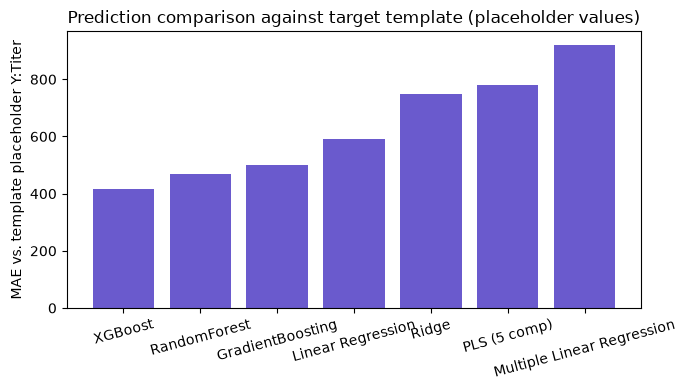

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(metrics_df["model"], metrics_df["MAE"], color="slateblue")
plt.ylabel("MAE vs. Titer")
plt.title("Prediction comparison against target Titer")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()